In [2]:
import os
import numpy as np
import h5py
from scipy import signal
from scipy.stats import pearsonr
import seaborn as sns
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import string

# Define path to data:
script_dir = os.path.dirname(os.path.abspath("Figure 1 Data Summary.ipynb"))
parent_dir = os.path.dirname(script_dir)
data_path = (parent_dir + '/dfs/')

In [5]:
# Load questionnaires data file:
Quest_data = pd.read_csv(data_path+'df_questionnaires.csv')
print(len(Quest_data))

200


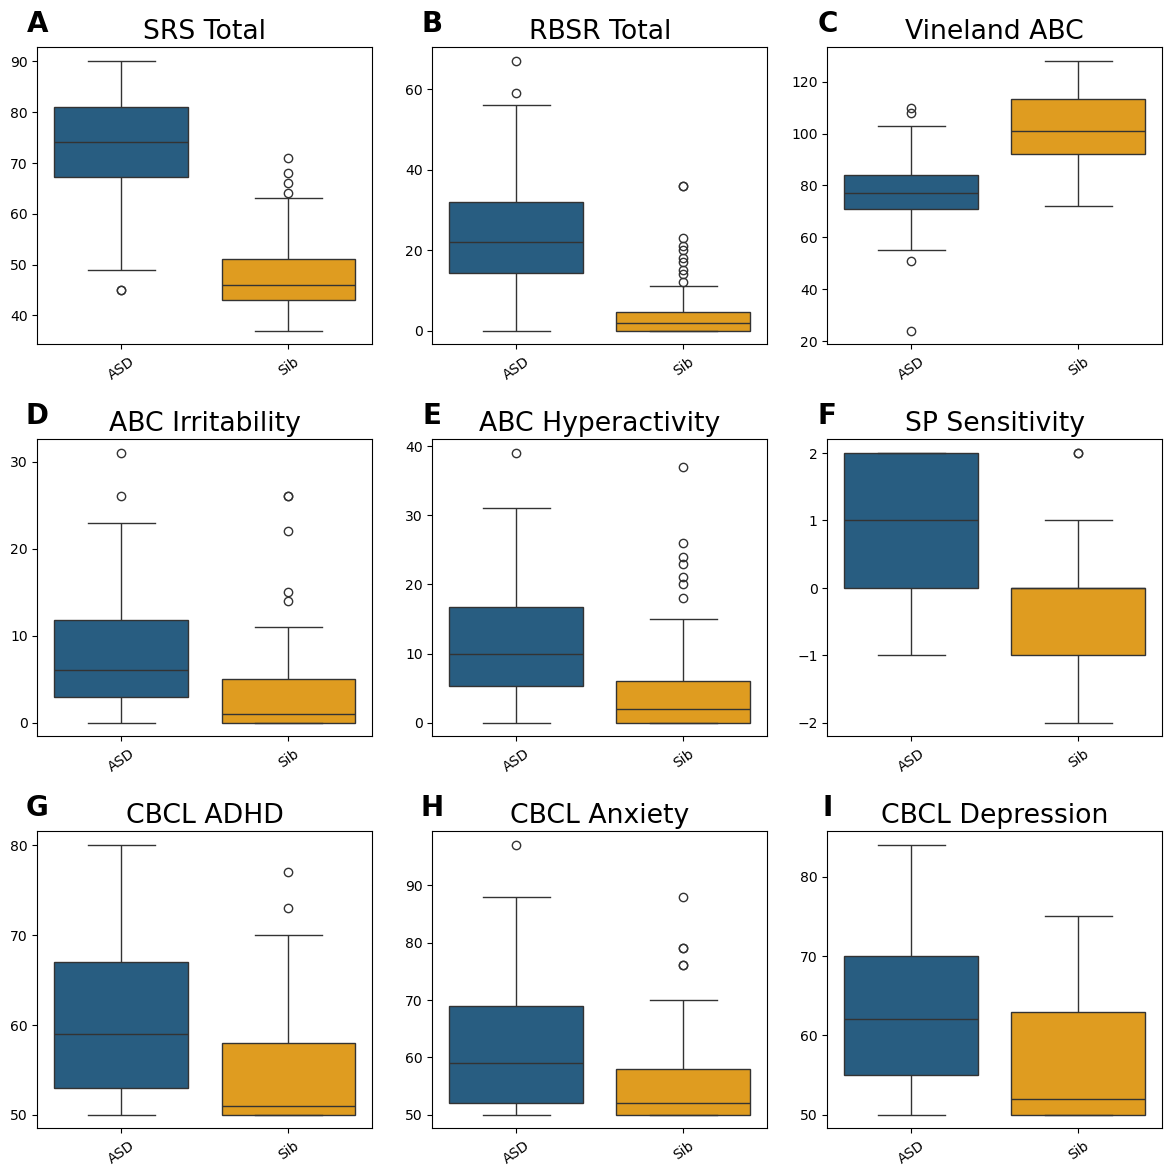

In [6]:
# Create a new column for the groups
Quest_data['Group'] = Quest_data.apply(lambda row: 'ASD' if row['asd'] else 'Sib', axis=1)

group_order = ['ASD', 'Sib']

# Define a color palette for the groups
hue_colors = {'ASD': '#19609080', 'Sib': '#FFA500'}

# List of metrics and titles
metrics = ['srs_total', 'rbsr_total', 'vineland_abc',
            'abc_irritability', 'abc_hyperactivity', 'sp_sensitivity_sd',
            'cbcl_dsm5_adhd', 'cbcl_dsm5_anxiety', 'cbcl_dsm5_depressive']
titles = ['SRS Total', 'RBSR Total', 'Vineland ABC',
            'ABC Irritability', 'ABC Hyperactivity', 'SP Sensitivity',
            'CBCL ADHD', 'CBCL Anxiety', 'CBCL Depression']

# Create a grid of subplots
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

# Flatten the axes for easier iteration
axes = axes.flatten()
# Set global font size for the plot
plt.rcParams.update({'font.size': 16})


# Plot each metric
for i, metric in enumerate(metrics):
    sns.boxplot(x='Group', y=metric, data=Quest_data, order=group_order, ax=axes[i], hue='Group', dodge=False, palette=hue_colors)
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='x', rotation=35)  # Rotate x-axis labels slightly for clarity
    # Add panel labels (A, B, C, ...)
    axes[i].text(0, 1.08, string.ascii_uppercase[i], transform=axes[i].transAxes,
                 fontsize=20, fontweight='bold', va='center', ha='center')

# Adjust layout and add more space between rows
plt.subplots_adjust(hspace=0.4)  # Increase vertical space between rows
plt.tight_layout()
plt.show()

In [7]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Add underscores to all column names in questionnaire dataframe:
Quest_data.columns = [col.replace(" ", "_") for col in Quest_data.columns]

sleep_measures = ['srs_total', 'rbsr_total', 'vineland_abc',
                'abc_irritability', 'abc_hyperactivity', 'sp_sensitivity_sd',
                'cbcl_dsm5_adhd', 'cbcl_dsm5_anxiety', 'cbcl_dsm5_depressive']

# Initialize a results dictionary to store variance components and ICCs
results = []

for measure in sleep_measures:
    print(f"Analyzing {measure} with ASD, Sex, and Age as fixed effects...")
    
    # Update the formula to include 'asd', 'sex', and 'age' as fixed effects
    formula = f"{measure} ~ asd + sex + age_months"
    
    # Fit the mixed-effects model
    model = smf.mixedlm(formula, Quest_data, groups=Quest_data["Parent_RID"])
    result = model.fit()
    
    # Extract variance components
    random_effects_variance = result.cov_re.iloc[0, 0]  # Between-group variance
    residual_variance = result.scale  # Within-group (residual) variance

    # Calculate the intraclass correlation coefficient (ICC)
    icc = random_effects_variance / (random_effects_variance + residual_variance)

    # Extract fixed-effect estimates and p-values
    asd_effect = result.params['asd[T.True]']
    asd_pvalue = result.pvalues['asd[T.True]']
    sex_effect = result.params['sex[T.Male]']  # Adjust for coding (e.g., if Male is treated as a category)
    sex_pvalue = result.pvalues['sex[T.Male]']
    age_effect = result.params['age_months']
    age_pvalue = result.pvalues['age_months']

    # Store results
    results.append({
        "Measure": measure,
        "Between-Pair Variance": random_effects_variance,
        "Within-Pair Variance": residual_variance,
        "ICC": icc,
        "ASD Effect (Beta)": asd_effect,
        "ASD Effect p-value": asd_pvalue,
        "Sex Effect (Beta)": sex_effect,
        "Sex Effect p-value": sex_pvalue,
        "Age Effect (Beta)": age_effect,
        "Age Effect p-value": age_pvalue
    })

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results)

# Display the results
print(results_df)


Analyzing srs_total with ASD, Sex, and Age as fixed effects...
Analyzing rbsr_total with ASD, Sex, and Age as fixed effects...
Analyzing vineland_abc with ASD, Sex, and Age as fixed effects...
Analyzing abc_irritability with ASD, Sex, and Age as fixed effects...
Analyzing abc_hyperactivity with ASD, Sex, and Age as fixed effects...
Analyzing sp_sensitivity_sd with ASD, Sex, and Age as fixed effects...
Analyzing cbcl_dsm5_adhd with ASD, Sex, and Age as fixed effects...
Analyzing cbcl_dsm5_anxiety with ASD, Sex, and Age as fixed effects...
Analyzing cbcl_dsm5_depressive with ASD, Sex, and Age as fixed effects...
                Measure  Between-Pair Variance  Within-Pair Variance  \
0             srs_total              19.256703             56.442429   
1            rbsr_total              25.305617             99.484924   
2          vineland_abc              30.666612            153.718188   
3      abc_irritability               9.281060             29.525545   
4     abc_hyperactivit